<a href="https://colab.research.google.com/github/Arprarthana17/VillaProject/blob/main/Villa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

STEP 1 - INSTALLING BLENDER
Blender 4.0.2
Blender script saved.

STEP 2 - GENERATING VILLA
RENDERING: 01_FOUNDATION
EGL Error (0x3001): EGL_NOT_INITIALIZED: EGL is not initialized, or could not be initialized, for the specified EGL display connection.

Managed to successfully fallback to surfaceless EGL rendering!

EGL Error (0x3009): EGL_BAD_MATCH: Arguments are inconsistent (for example, a valid context requires buffers not supplied by a valid surface).
EGL Error (0x3001): EGL_NOT_INITIALIZED: EGL is not initialized, or could not be initialized, for the specified EGL display connection.

Managed to successfully fallback to surfaceless EGL rendering!

Blender 4.0.2
Saved: '/content/MODERN_VILLA_1740_CLEAN/images/01_FOUNDATION.png'
Time: 00:06.67 (Saving: 00:00.44)

Render operator: {'FINISHED'}
CREATED: /content/MODERN_VILLA_1740_CLEAN/images/01_FOUNDATION.png SIZE: 533195
RENDERING: 02_GROUND_FLOOR
Saved: '/content/MODERN_VILLA_1740_CLEAN/images/02_GROUND_FLOOR.png'
Time: 00:01.41 (S

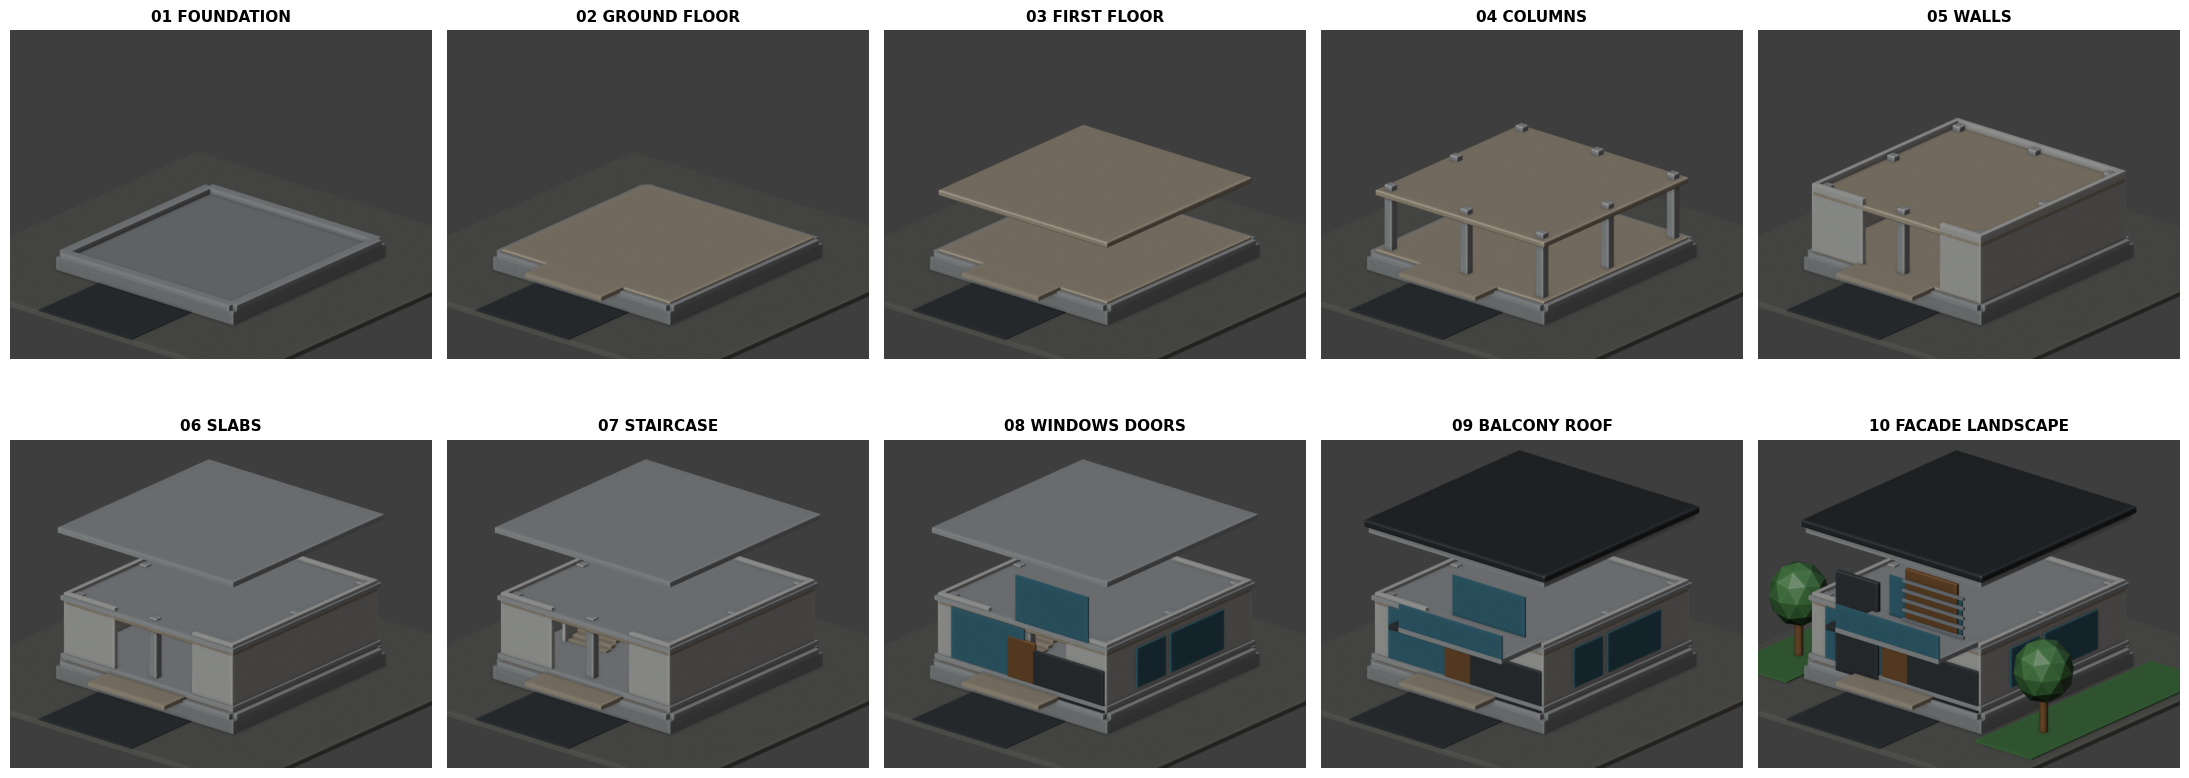


STEP 5 - FINAL ASSEMBLED VILLA


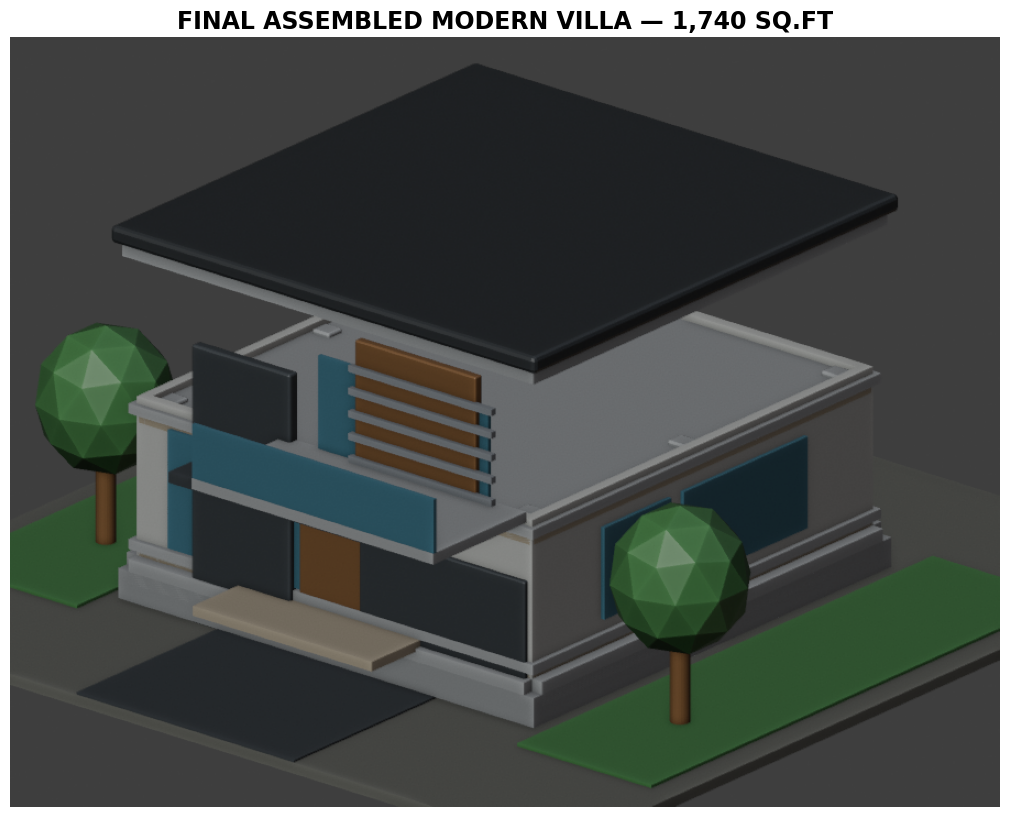

✅ FINAL IMAGE CREATED

FINAL RESULT
PNG images: 11 / 11
Villa area: 1,740 sq.ft
Floor area: 870 + 870 sq.ft
Building: G+1 Modern Villa
GLB: ✅ CREATED
GLB size: 130.0 KB

DATASET LOCATION:
/content/MODERN_VILLA_1740_CLEAN

IMAGE LOCATION:
/content/MODERN_VILLA_1740_CLEAN/images

MODEL LOCATION:
/content/MODERN_VILLA_1740_CLEAN/model

DONE


In [1]:
# ================================================================
# CLEAN MODERN VILLA DATASET - GOOGLE COLAB
# ================================================================
#
# ONE MODERN 1,740 SQ.FT G+1 VILLA
#
# OUTPUT:
#   01 Foundation
#   02 Ground Floor
#   03 First Floor
#   04 Columns
#   05 Walls
#   06 Slabs
#   07 Staircase
#   08 Windows + Doors
#   09 Balcony + Roof
#   10 Facade + Landscape
#   11 FINAL ASSEMBLED VILLA
#
# IMPORTANT:
#   This version renders progressively:
#
#   Foundation
#       ↓
#   Foundation + Ground Floor
#       ↓
#   + First Floor
#       ↓
#   + Columns
#       ↓
#   + Walls
#       ↓
#   + Slabs
#       ↓
#   + Staircase
#       ↓
#   + Windows + Doors
#       ↓
#   + Balcony + Roof
#       ↓
#   + Facade + Landscape
#       ↓
#   FINAL COMPLETE VILLA
#
# Blender Workbench is used because it is reliable in Colab.
# ================================================================

import os
import sys
import subprocess
import shutil
from pathlib import Path

# ================================================================
# 1. INSTALL BLENDER
# ================================================================

print("=" * 70)
print("STEP 1 - INSTALLING BLENDER")
print("=" * 70)

subprocess.run(
    ["apt-get", "update", "-qq"],
    check=True
)

subprocess.run(
    ["apt-get", "install", "-y", "-qq", "blender"],
    check=True
)

# Check Blender
version = subprocess.run(
    ["blender", "--version"],
    capture_output=True,
    text=True
)

print(version.stdout.splitlines()[0])

# ================================================================
# 2. INSTALL PYTHON PACKAGES
# ================================================================

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pillow",
        "matplotlib"
    ],
    check=True
)

# ================================================================
# 3. CLEAN OUTPUT
# ================================================================

BASE_DIR = Path("/content/MODERN_VILLA_1740_CLEAN")

if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)

IMAGE_DIR = BASE_DIR / "images"
MODEL_DIR = BASE_DIR / "model"

IMAGE_DIR.mkdir(parents=True)
MODEL_DIR.mkdir(parents=True)

BLENDER_SCRIPT = BASE_DIR / "villa.py"
BLENDER_LOG = BASE_DIR / "blender.log"

# ================================================================
# 4. BLENDER SCRIPT
# ================================================================

script = r'''
import bpy
import os
import math

from mathutils import Vector

# ============================================================
# PATHS
# ============================================================

BASE_DIR = os.environ["VILLA_BASE_DIR"]

IMAGE_DIR = os.path.join(BASE_DIR, "images")
MODEL_DIR = os.path.join(BASE_DIR, "model")

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# DIMENSIONS
# ============================================================

FT = 0.3048

# 29 ft x 30 ft = 870 sq.ft
# 870 + 870 = 1,740 sq.ft

WIDTH = 29.0 * FT
DEPTH = 30.0 * FT

TOTAL_AREA = 1740

GROUND_Z = 0.0
FIRST_Z = 3.35

WALL_HEIGHT = 3.0
WALL_THICKNESS = 0.20

# ============================================================
# CLEAN SCENE
# ============================================================

bpy.ops.object.select_all(action="SELECT")
bpy.ops.object.delete(use_global=False)

for collection in list(bpy.data.collections):

    if collection.name != "Collection":

        bpy.data.collections.remove(
            collection
        )

# ============================================================
# SCENE
# ============================================================

scene = bpy.context.scene

# IMPORTANT:
# Workbench works reliably in background/headless Blender.

scene.render.engine = "BLENDER_WORKBENCH"

scene.render.resolution_x = 900
scene.render.resolution_y = 700
scene.render.resolution_percentage = 100

scene.render.image_settings.file_format = "PNG"

scene.render.film_transparent = False

# Workbench settings

try:
    scene.display.shading.light = "STUDIO"
except:
    pass

try:
    scene.display.shading.color_type = "MATERIAL"
except:
    pass

try:
    scene.display.shading.show_shadows = True
except:
    pass

try:
    scene.display.shading.show_cavity = True
except:
    pass

try:
    scene.display.shading.cavity_type = "WORLD"
except:
    pass

try:
    scene.display.shading.curvature_ridge_factor = 1.5
except:
    pass

try:
    scene.display.shading.curvature_valley_factor = 1.0
except:
    pass

# ============================================================
# WORLD
# ============================================================

if scene.world is None:

    scene.world = bpy.data.worlds.new("World")

scene.world.color = (
    0.055,
    0.055,
    0.055
)

# ============================================================
# COLLECTION CREATION
# ============================================================

def make_collection(name):

    c = bpy.data.collections.get(name)

    if c is None:

        c = bpy.data.collections.new(name)

        scene.collection.children.link(c)

    return c


COL_SITE = make_collection("SITE")
COL_FOUNDATION = make_collection("FOUNDATION")
COL_GROUND = make_collection("GROUND_FLOOR")
COL_FIRST = make_collection("FIRST_FLOOR")
COL_COLUMNS = make_collection("COLUMNS")
COL_WALLS = make_collection("WALLS")
COL_SLABS = make_collection("SLABS")
COL_STAIR = make_collection("STAIRCASE")
COL_OPENINGS = make_collection("WINDOWS_DOORS")
COL_ROOF = make_collection("BALCONY_ROOF")
COL_FACADE = make_collection("FACADE_LANDSCAPE")

ALL_COLLECTIONS = [

    COL_SITE,
    COL_FOUNDATION,
    COL_GROUND,
    COL_FIRST,
    COL_COLUMNS,
    COL_WALLS,
    COL_SLABS,
    COL_STAIR,
    COL_OPENINGS,
    COL_ROOF,
    COL_FACADE
]

# ============================================================
# MATERIALS
# ============================================================

def create_material(name, color):

    mat = bpy.data.materials.get(name)

    if mat is None:

        mat = bpy.data.materials.new(name)

    mat.diffuse_color = (
        color[0],
        color[1],
        color[2],
        1.0
    )

    return mat


MAT_SITE = create_material(
    "Site",
    (0.25, 0.25, 0.22)
)

MAT_FOUNDATION = create_material(
    "Foundation",
    (0.48, 0.49, 0.50)
)

MAT_CONCRETE = create_material(
    "Concrete",
    (0.58, 0.59, 0.60)
)

MAT_FLOOR = create_material(
    "Floor",
    (0.68, 0.58, 0.43)
)

MAT_WALL = create_material(
    "Modern White Wall",
    (0.86, 0.86, 0.82)
)

MAT_DARK = create_material(
    "Dark Modern",
    (0.08, 0.09, 0.10)
)

MAT_WOOD = create_material(
    "Wood",
    (0.34, 0.17, 0.07)
)

MAT_GLASS = create_material(
    "Glass",
    (0.10, 0.28, 0.38)
)

MAT_GREEN = create_material(
    "Landscape",
    (0.12, 0.38, 0.12)
)

MAT_ROOF = create_material(
    "Roof",
    (0.055, 0.06, 0.065)
)

MAT_METAL = create_material(
    "Metal",
    (0.35, 0.37, 0.40)
)

# ============================================================
# MOVE OBJECT TO COLLECTION
# ============================================================

def move_to(obj, collection):

    for c in list(obj.users_collection):

        c.objects.unlink(obj)

    collection.objects.link(obj)

# ============================================================
# BOX
# ============================================================

def create_box(
    name,
    location,
    dimensions,
    material,
    collection,
    bevel=0.0
):

    bpy.ops.mesh.primitive_cube_add(
        size=1,
        location=location
    )

    obj = bpy.context.object

    obj.name = name

    obj.dimensions = dimensions

    bpy.ops.object.transform_apply(
        location=False,
        rotation=False,
        scale=True
    )

    if material:

        obj.data.materials.append(
            material
        )

    move_to(
        obj,
        collection
    )

    if bevel > 0:

        modifier = obj.modifiers.new(
            "Architectural Edge",
            "BEVEL"
        )

        modifier.width = bevel
        modifier.segments = 2

    return obj

# ============================================================
# CYLINDER
# ============================================================

def create_cylinder(
    name,
    location,
    radius,
    depth,
    material,
    collection
):

    bpy.ops.mesh.primitive_cylinder_add(
        vertices=24,
        radius=radius,
        depth=depth,
        location=location
    )

    obj = bpy.context.object

    obj.name = name

    obj.data.materials.append(
        material
    )

    move_to(
        obj,
        collection
    )

    return obj

# ============================================================
# 01 - SITE
# ============================================================

site_w = WIDTH + 8.0
site_d = DEPTH + 8.0

create_box(
    "SITE_BASE",
    (0, 0, -0.12),
    (site_w, site_d, 0.20),
    MAT_SITE,
    COL_SITE
)

# Driveway

create_box(
    "DRIVEWAY",
    (0, -DEPTH/2 - 2.0, 0.01),
    (WIDTH * 0.55, 4.0, 0.04),
    MAT_DARK,
    COL_SITE
)

# ============================================================
# 02 - FOUNDATION
# ============================================================

create_box(
    "FOUNDATION_MAIN",
    (0, 0, 0.30),
    (WIDTH + 0.45, DEPTH + 0.45, 0.55),
    MAT_FOUNDATION,
    COL_FOUNDATION
)

# Foundation perimeter beams

create_box(
    "FOUNDATION_FRONT",
    (0, -DEPTH/2, 0.58),
    (WIDTH, 0.45, 0.45),
    MAT_CONCRETE,
    COL_FOUNDATION
)

create_box(
    "FOUNDATION_REAR",
    (0, DEPTH/2, 0.58),
    (WIDTH, 0.45, 0.45),
    MAT_CONCRETE,
    COL_FOUNDATION
)

create_box(
    "FOUNDATION_LEFT",
    (-WIDTH/2, 0, 0.58),
    (0.45, DEPTH, 0.45),
    MAT_CONCRETE,
    COL_FOUNDATION
)

create_box(
    "FOUNDATION_RIGHT",
    (WIDTH/2, 0, 0.58),
    (0.45, DEPTH, 0.45),
    MAT_CONCRETE,
    COL_FOUNDATION
)

# ============================================================
# 03 - GROUND FLOOR
# ============================================================

create_box(
    "GROUND_FLOOR",
    (0, 0, 0.78),
    (WIDTH, DEPTH, 0.25),
    MAT_FLOOR,
    COL_GROUND,
    bevel=0.05
)

# Entrance platform

create_box(
    "ENTRANCE_PLATFORM",
    (0, -DEPTH/2 - 0.70, 0.84),
    (4.0, 1.4, 0.18),
    MAT_FLOOR,
    COL_GROUND
)

# ============================================================
# 04 - FIRST FLOOR
# ============================================================

create_box(
    "FIRST_FLOOR",
    (0, 0, FIRST_Z),
    (WIDTH, DEPTH, 0.25),
    MAT_FLOOR,
    COL_FIRST,
    bevel=0.05
)

# ============================================================
# 05 - COLUMNS
# ============================================================

column_positions = [

    (-WIDTH/2 + 0.45, -DEPTH/2 + 0.45),
    ( WIDTH/2 - 0.45, -DEPTH/2 + 0.45),

    (-WIDTH/2 + 0.45, DEPTH/2 - 0.45),
    ( WIDTH/2 - 0.45, DEPTH/2 - 0.45),

    (-WIDTH/2 + 0.45, 0),
    ( WIDTH/2 - 0.45, 0),

    (0, -DEPTH/2 + 0.45),
    (0, DEPTH/2 - 0.45)
]

for i, (x, y) in enumerate(
    column_positions
):

    create_box(
        f"COLUMN_{i+1:02d}",
        (x, y, 2.20),
        (0.38, 0.38, 3.0),
        MAT_CONCRETE,
        COL_COLUMNS,
        bevel=0.04
    )

# ============================================================
# 06 - WALLS
# ============================================================

front_y = -DEPTH/2 + WALL_THICKNESS/2

# Rear wall

create_box(
    "REAR_WALL",
    (0, DEPTH/2 - WALL_THICKNESS/2, 2.25),
    (WIDTH, WALL_THICKNESS, WALL_HEIGHT),
    MAT_WALL,
    COL_WALLS
)

# Left wall

create_box(
    "LEFT_WALL",
    (-WIDTH/2 + WALL_THICKNESS/2, 0, 2.25),
    (WALL_THICKNESS, DEPTH, WALL_HEIGHT),
    MAT_WALL,
    COL_WALLS
)

# Right wall

create_box(
    "RIGHT_WALL",
    (WIDTH/2 - WALL_THICKNESS/2, 0, 2.25),
    (WALL_THICKNESS, DEPTH, WALL_HEIGHT),
    MAT_WALL,
    COL_WALLS
)

# Front wall split for modern opening

create_box(
    "FRONT_LEFT_WALL",
    (-WIDTH*0.35, front_y, 2.25),
    (WIDTH*0.30, WALL_THICKNESS, WALL_HEIGHT),
    MAT_WALL,
    COL_WALLS
)

create_box(
    "FRONT_RIGHT_WALL",
    (WIDTH*0.38, front_y, 2.25),
    (WIDTH*0.24, WALL_THICKNESS, WALL_HEIGHT),
    MAT_WALL,
    COL_WALLS
)

# ============================================================
# 07 - SLABS
# ============================================================

create_box(
    "GROUND_SLAB",
    (0, 0, 1.02),
    (WIDTH + 0.20, DEPTH + 0.20, 0.18),
    MAT_CONCRETE,
    COL_SLABS
)

create_box(
    "FIRST_SLAB",
    (0, 0, FIRST_Z + 0.18),
    (WIDTH + 0.20, DEPTH + 0.20, 0.18),
    MAT_CONCRETE,
    COL_SLABS
)

create_box(
    "ROOF_SLAB",
    (0, 0, FIRST_Z + WALL_HEIGHT + 0.12),
    (WIDTH + 0.35, DEPTH + 0.35, 0.22),
    MAT_CONCRETE,
    COL_SLABS
)

# ============================================================
# 08 - STAIRCASE
# ============================================================

step_count = 18

step_h = 2.30 / step_count
step_depth = 0.30
step_width = 2.10

stair_x = -WIDTH/2 + 2.2
stair_y = -2.0

for i in range(step_count):

    z = 1.0 + i * step_h

    y = stair_y + i * step_depth

    create_box(
        f"STAIR_{i+1:02d}",
        (stair_x, y, z),
        (step_width, step_depth, step_h),
        MAT_FLOOR,
        COL_STAIR
    )

# Stair wall

create_box(
    "STAIR_SIDE_WALL",
    (
        stair_x - step_width/2,
        stair_y + step_count*step_depth/2,
        2.1
    ),
    (
        0.15,
        step_count*step_depth,
        2.3
    ),
    MAT_WALL,
    COL_STAIR
)

# ============================================================
# 09 - WINDOWS + DOORS
# ============================================================

# Main door

create_box(
    "MAIN_DOOR",
    (0, front_y - 0.12, 1.75),
    (1.45, 0.12, 2.25),
    MAT_WOOD,
    COL_OPENINGS,
    bevel=0.03
)

# Garage door

create_box(
    "GARAGE_DOOR",
    (WIDTH*0.28, front_y - 0.13, 1.45),
    (3.7, 0.12, 2.30),
    MAT_DARK,
    COL_OPENINGS,
    bevel=0.03
)

# Front glass

create_box(
    "FRONT_GLASS",
    (-WIDTH*0.20, front_y - 0.13, 2.25),
    (3.8, 0.08, 2.20),
    MAT_GLASS,
    COL_OPENINGS
)

# First-floor glass

create_box(
    "FIRST_FLOOR_GLASS",
    (WIDTH*0.18, front_y - 0.13, FIRST_Z + 1.25),
    (3.8, 0.08, 2.0),
    MAT_GLASS,
    COL_OPENINGS
)

# Side windows

for y in [-6*FT, 1*FT, 6*FT]:

    create_box(
        "LEFT_WINDOW",
        (-WIDTH/2 - 0.04, y, 2.20),
        (0.08, 1.8, 1.7),
        MAT_GLASS,
        COL_OPENINGS
    )

    create_box(
        "RIGHT_WINDOW",
        (WIDTH/2 + 0.04, y, 2.20),
        (0.08, 1.8, 1.7),
        MAT_GLASS,
        COL_OPENINGS
    )

# ============================================================
# 10 - BALCONY + ROOF
# ============================================================

balcony_z = FIRST_Z + 0.42

create_box(
    "BALCONY_DECK",
    (WIDTH*0.18, -DEPTH/2 - 1.25, balcony_z),
    (5.4, 2.5, 0.20),
    MAT_CONCRETE,
    COL_ROOF
)

# Glass railing

create_box(
    "BALCONY_RAILING",
    (WIDTH*0.18, -DEPTH/2 - 2.45, balcony_z + 0.55),
    (5.4, 0.08, 1.10),
    MAT_GLASS,
    COL_ROOF
)

# Flat modern roof

roof_z = FIRST_Z + WALL_HEIGHT + 0.42

create_box(
    "MODERN_FLAT_ROOF",
    (0, 0, roof_z),
    (WIDTH + 0.65, DEPTH + 0.65, 0.32),
    MAT_ROOF,
    COL_ROOF,
    bevel=0.08
)

# Entrance canopy

create_box(
    "ENTRANCE_CANOPY",
    (0, -DEPTH/2 - 0.70, FIRST_Z - 0.15),
    (5.0, 1.5, 0.20),
    MAT_DARK,
    COL_ROOF
)

# ============================================================
# 11 - FACADE + LANDSCAPE
# ============================================================

# Vertical dark architectural element

create_box(
    "DARK_FACADE_PANEL",
    (-WIDTH*0.22, front_y - 0.17, 2.55),
    (2.20, 0.22, 5.15),
    MAT_DARK,
    COL_FACADE,
    bevel=0.04
)

# Wooden upper facade

create_box(
    "WOOD_FACADE_PANEL",
    (WIDTH*0.22, front_y - 0.18, FIRST_Z + 1.45),
    (2.70, 0.18, 2.70),
    MAT_WOOD,
    COL_FACADE,
    bevel=0.03
)

# Horizontal facade fins

for i in range(5):

    create_box(
        f"FACADE_FIN_{i+1:02d}",
        (
            WIDTH*0.24,
            front_y - 0.30,
            FIRST_Z + 0.60 + i*0.42
        ),
        (
            3.2,
            0.12,
            0.12
        ),
        MAT_METAL,
        COL_FACADE
    )

# Landscape

create_box(
    "LANDSCAPE_LEFT",
    (-WIDTH/2 - 2.0, 0, 0.03),
    (3.0, DEPTH + 2.0, 0.06),
    MAT_GREEN,
    COL_FACADE
)

create_box(
    "LANDSCAPE_RIGHT",
    (WIDTH/2 + 2.0, 0, 0.03),
    (3.0, DEPTH + 2.0, 0.06),
    MAT_GREEN,
    COL_FACADE
)

# Trees

for i, x in enumerate(
    [-WIDTH/2 - 2.0, WIDTH/2 + 2.0]
):

    create_cylinder(
        f"TREE_TRUNK_{i}",
        (x, -3.0, 1.2),
        0.18,
        2.4,
        MAT_WOOD,
        COL_FACADE
    )

    bpy.ops.mesh.primitive_ico_sphere_add(
        subdivisions=2,
        radius=1.0,
        location=(x, -3.0, 2.7)
    )

    tree = bpy.context.object

    tree.name = f"TREE_TOP_{i}"

    tree.scale = (
        1.25,
        1.25,
        1.35
    )

    tree.data.materials.append(
        MAT_GREEN
    )

    move_to(
        tree,
        COL_FACADE
    )

# ============================================================
# CAMERA
# ============================================================

bpy.ops.object.camera_add()

camera = bpy.context.object

camera.name = "ARCHITECTURAL_CAMERA"

scene.camera = camera

camera.data.type = "ORTHO"

camera.data.ortho_scale = 17.0

camera.data.lens = 50

camera.data.clip_start = 0.01

camera.data.clip_end = 1000

camera.location = (
    15.0,
    -18.0,
    12.5
)

def look_at(obj, target):

    direction = (
        Vector(target) -
        obj.location
    )

    obj.rotation_euler = (
        direction.to_track_quat(
            "-Z",
            "Y"
        ).to_euler()
    )

look_at(
    camera,
    (0, 0, 3.0)
)

# ============================================================
# VISIBILITY SYSTEM
# ============================================================

# Progressive construction:
#
# Stage 1 = foundation
# Stage 2 = foundation + ground
# Stage 3 = + first floor
# Stage 4 = + columns
# Stage 5 = + walls
# Stage 6 = + slabs
# Stage 7 = + staircase
# Stage 8 = + windows/doors
# Stage 9 = + balcony/roof
# Stage 10 = + facade/landscape
# Stage 11 = everything

STAGES = [

    (
        "01_FOUNDATION",
        [
            COL_SITE,
            COL_FOUNDATION
        ]
    ),

    (
        "02_GROUND_FLOOR",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND
        ]
    ),

    (
        "03_FIRST_FLOOR",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST
        ]
    ),

    (
        "04_COLUMNS",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS
        ]
    ),

    (
        "05_WALLS",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS,
            COL_WALLS
        ]
    ),

    (
        "06_SLABS",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS,
            COL_WALLS,
            COL_SLABS
        ]
    ),

    (
        "07_STAIRCASE",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS,
            COL_WALLS,
            COL_SLABS,
            COL_STAIR
        ]
    ),

    (
        "08_WINDOWS_DOORS",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS,
            COL_WALLS,
            COL_SLABS,
            COL_STAIR,
            COL_OPENINGS
        ]
    ),

    (
        "09_BALCONY_ROOF",
        [
            COL_SITE,
            COL_FOUNDATION,
            COL_GROUND,
            COL_FIRST,
            COL_COLUMNS,
            COL_WALLS,
            COL_SLABS,
            COL_STAIR,
            COL_OPENINGS,
            COL_ROOF
        ]
    ),

    (
        "10_FACADE_LANDSCAPE",
        ALL_COLLECTIONS
    ),

    (
        "11_FINAL_ASSEMBLED",
        ALL_COLLECTIONS
    )
]

# ============================================================
# VISIBILITY
# ============================================================

def set_visibility(active):

    active_set = set(
        c.name
        for c in active
    )

    for c in ALL_COLLECTIONS:

        visible = c.name in active_set

        c.hide_render = not visible

        for obj in c.objects:

            obj.hide_render = not visible

# ============================================================
# RENDER ALL STAGES
# ============================================================

successful = []

for stage_name, active in STAGES:

    print(
        "RENDERING:",
        stage_name,
        flush=True
    )

    set_visibility(active)

    output_path = os.path.join(
        IMAGE_DIR,
        stage_name + ".png"
    )

    scene.render.filepath = output_path

    try:

        result = bpy.ops.render.render(
            write_still=True
        )

        print(
            "Render operator:",
            result,
            flush=True
        )

    except Exception as e:

        print(
            "RENDER ERROR:",
            repr(e),
            flush=True
        )

        continue

    if os.path.exists(output_path):

        size = os.path.getsize(
            output_path
        )

        print(
            "CREATED:",
            output_path,
            "SIZE:",
            size,
            flush=True
        )

        if size > 5000:

            successful.append(
                output_path
            )

    else:

        print(
            "FAILED - FILE NOT FOUND:",
            output_path,
            flush=True
        )

# ============================================================
# FINAL VISIBILITY
# ============================================================

set_visibility(
    ALL_COLLECTIONS
)

# ============================================================
# EXPORT GLB
# ============================================================

print(
    "EXPORTING GLB...",
    flush=True
)

glb_path = os.path.join(
    MODEL_DIR,
    "VILLA_000001_MODERN.glb"
)

bpy.ops.object.select_all(
    action="DESELECT"
)

for c in ALL_COLLECTIONS:

    for obj in c.objects:

        obj.hide_render = False
        obj.select_set(True)

try:

    bpy.ops.export_scene.gltf(
        filepath=glb_path,
        export_format="GLB",
        use_selection=True
    )

    print(
        "GLB CREATED:",
        glb_path,
        flush=True
    )

except Exception as e:

    print(
        "GLB EXPORT FAILED:",
        repr(e),
        flush=True
    )

# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 70)
print("BLENDER GENERATION FINISHED")
print("=" * 70)

print(
    "Successful PNGs:",
    len(successful),
    "/ 11"
)

for path in successful:

    print(
        os.path.basename(path)
    )

print("=" * 70)
'''

# ================================================================
# 5. SAVE SCRIPT
# ================================================================

with open(BLENDER_SCRIPT, "w") as f:
    f.write(script)

print("Blender script saved.")

# ================================================================
# 6. RUN BLENDER
# ================================================================

print()
print("=" * 70)
print("STEP 2 - GENERATING VILLA")
print("=" * 70)

env = os.environ.copy()
env["VILLA_BASE_DIR"] = str(BASE_DIR)

result = subprocess.run(
    [
        "blender",
        "--background",
        "--factory-startup",
        "--python",
        str(BLENDER_SCRIPT)
    ],
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

log = result.stdout

with open(BLENDER_LOG, "w") as f:
    f.write(log)

print(log)

print()
print("BLENDER RETURN CODE:", result.returncode)

# ================================================================
# 7. VERIFY FILES
# ================================================================

from PIL import Image

expected = [
    "01_FOUNDATION.png",
    "02_GROUND_FLOOR.png",
    "03_FIRST_FLOOR.png",
    "04_COLUMNS.png",
    "05_WALLS.png",
    "06_SLABS.png",
    "07_STAIRCASE.png",
    "08_WINDOWS_DOORS.png",
    "09_BALCONY_ROOF.png",
    "10_FACADE_LANDSCAPE.png",
    "11_FINAL_ASSEMBLED.png"
]

valid = []

print()
print("=" * 70)
print("STEP 3 - VERIFYING PNG FILES")
print("=" * 70)

for filename in expected:

    path = IMAGE_DIR / filename

    if not path.exists():

        print(
            "❌ MISSING:",
            filename
        )

        continue

    try:

        with Image.open(path) as img:

            img.verify()

        size = path.stat().st_size

        if size > 5000:

            valid.append(path)

            print(
                "✅",
                filename,
                f"({size/1024:.1f} KB)"
            )

        else:

            print(
                "❌ TOO SMALL:",
                filename
            )

    except Exception as e:

        print(
            "❌ INVALID:",
            filename,
            e
        )

# ================================================================
# 8. DISPLAY THE 10 SPLIT IMAGES
# ================================================================

import matplotlib.pyplot as plt

component_paths = [
    IMAGE_DIR / x
    for x in expected[:10]
    if (IMAGE_DIR / x).exists()
]

print()
print("=" * 70)
print(
    "STEP 4 - DISPLAYING COMPONENT / CONSTRUCTION IMAGES"
)
print("=" * 70)

if len(component_paths) > 0:

    fig, axes = plt.subplots(
        2,
        5,
        figsize=(22, 9)
    )

    for i, ax in enumerate(
        axes.flat
    ):

        if i < len(component_paths):

            path = component_paths[i]

            img = Image.open(path)

            ax.imshow(img)

            title = (
                path.stem
                .replace("_", " ")
            )

            ax.set_title(
                title,
                fontsize=11,
                fontweight="bold"
            )

        ax.axis("off")

    plt.tight_layout()

    preview_path = (
        BASE_DIR /
        "10_COMPONENT_IMAGES.png"
    )

    plt.savefig(
        preview_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "❌ NO COMPONENT IMAGES WERE GENERATED"
    )

# ================================================================
# 9. DISPLAY FINAL IMAGE
# ================================================================

final_path = (
    IMAGE_DIR /
    "11_FINAL_ASSEMBLED.png"
)

print()
print("=" * 70)
print("STEP 5 - FINAL ASSEMBLED VILLA")
print("=" * 70)

if final_path.exists():

    try:

        final_image = Image.open(
            final_path
        )

        plt.figure(
            figsize=(14, 10)
        )

        plt.imshow(
            final_image
        )

        plt.title(
            "FINAL ASSEMBLED MODERN VILLA — 1,740 SQ.FT",
            fontsize=17,
            fontweight="bold"
        )

        plt.axis("off")

        plt.show()

        print(
            "✅ FINAL IMAGE CREATED"
        )

    except Exception as e:

        print(
            "❌ FINAL IMAGE ERROR:",
            e
        )

else:

    print(
        "❌ FINAL IMAGE NOT FOUND"
    )

# ================================================================
# 10. FINAL SUMMARY
# ================================================================

glb_path = (
    MODEL_DIR /
    "VILLA_000001_MODERN.glb"
)

print()
print("=" * 70)
print("FINAL RESULT")
print("=" * 70)

print(
    f"PNG images: {len(valid)} / 11"
)

print(
    "Villa area: 1,740 sq.ft"
)

print(
    "Floor area: 870 + 870 sq.ft"
)

print(
    "Building: G+1 Modern Villa"
)

if glb_path.exists():

    print(
        "GLB: ✅ CREATED"
    )

    print(
        f"GLB size: {glb_path.stat().st_size/1024:.1f} KB"
    )

else:

    print(
        "GLB: ❌ NOT CREATED"
    )

print()
print(
    "DATASET LOCATION:"
)
print(BASE_DIR)

print()
print(
    "IMAGE LOCATION:"
)
print(IMAGE_DIR)

print()
print(
    "MODEL LOCATION:"
)
print(MODEL_DIR)

print()
print("=" * 70)
print("DONE")
print("=" * 70)